In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [6]:
from google.colab import files
import pandas as pd

# Upload training file only
print("Please upload train_data.csv")
files.upload()

# Load the training data
df = pd.read_csv('train_data.csv')

print("\n✅ Training data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

Please upload train_data.csv


Saving train_data.csv to train_data (2).csv

✅ Training data loaded successfully!
Shape: (304, 13)

First few rows:
    Loan_ID  Gender Married Dependents Education Self_Employed  \
0  LP001430  Female      No          0  Graduate            No   
1  LP002347    Male     Yes          0  Graduate            No   
2  LP001528    Male      No          0  Graduate            No   
3  LP002974    Male     Yes          0  Graduate            No   
4  LP002368    Male     Yes          2  Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4166                0.0        44.0             360.0   
1             3246             1417.0       138.0             360.0   
2             6277                0.0       118.0             360.0   
3             3232             1950.0       108.0             360.0   
4             5935                0.0       133.0             360.0   

   Credit_History Property_Area Loan_Status  
0             

In [7]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
299,LP001367,Male,Yes,1,Graduate,No,3052,1030.0,100.0,360.0,1.0,Urban,Y
300,LP001606,Male,Yes,0,Graduate,No,3497,1964.0,116.0,360.0,1.0,Rural,Y
301,LP002366,Male,Yes,0,Graduate,No,2666,4300.0,121.0,360.0,1.0,Rural,Y
302,LP002777,Male,Yes,0,Graduate,No,2785,2016.0,110.0,360.0,1.0,Rural,Y
303,LP001579,Male,No,0,Graduate,No,2237,0.0,63.0,480.0,0.0,Semiurban,N


In [8]:
print(df['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
Y    0.707237
N    0.292763
Name: proportion, dtype: float64


In [9]:
print(df.duplicated().sum())

0


In [10]:
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [11]:
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
  df[col] = le.fit_transform(df[col])

print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [12]:
#null values percentage
df.isna().sum()/len(df)*100

,0
Loan_ID,0.000000
Gender,0.000000
Married,0.000000
Dependents,2.302632
Education,0.000000
Self_Employed,0.000000
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,0.000000
Loan_Amount_Term,2.960526


In [13]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_708/3390244665.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_708/3390244665.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [14]:
df['Loan_Amount_Term']=df["Loan_Amount_Term"].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            304 non-null    int64  
 1   Gender             304 non-null    int64  
 2   Married            304 non-null    int64  
 3   Dependents         304 non-null    object 
 4   Education          304 non-null    int64  
 5   Self_Employed      304 non-null    int64  
 6   ApplicantIncome    304 non-null    int64  
 7   CoapplicantIncome  304 non-null    float64
 8   LoanAmount         304 non-null    float64
 9   Loan_Amount_Term   304 non-null    float64
 10  Credit_History     304 non-null    float64
 11  Property_Area      304 non-null    int64  
 12  Loan_Status        304 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 31.0+ KB


In [16]:
df.describe()

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,304.00000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,151.50000,0.792763,0.605263,0.269737,0.194079,3583.828947,1220.645132,105.282895,342.631579,0.835526,1.036184,0.707237
std,87.90146,0.429690,0.489600,0.444555,0.518787,1366.102888,1732.098606,28.696412,66.256595,0.371316,0.780543,0.455781
min,0.00000,0.000000,0.000000,0.000000,0.000000,210.000000,0.000000,17.000000,12.000000,0.000000,0.000000,0.000000
25%,75.75000,1.000000,0.000000,0.000000,0.000000,2651.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.000000
50%,151.50000,1.000000,1.000000,0.000000,0.000000,3365.500000,953.000000,110.500000,360.000000,1.000000,1.000000,1.000000
75%,227.25000,1.000000,1.000000,1.000000,0.000000,4284.250000,2045.000000,128.000000,360.000000,1.000000,2.000000,1.000000
max,303.00000,2.000000,1.000000,1.000000,2.000000,9703.000000,20000.000000,150.000000,480.000000,1.000000,2.000000,1.000000


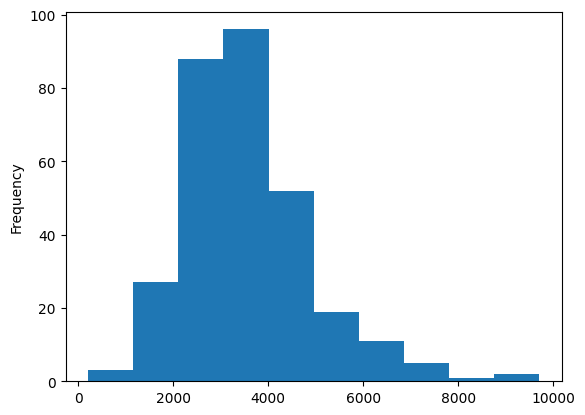

In [17]:
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

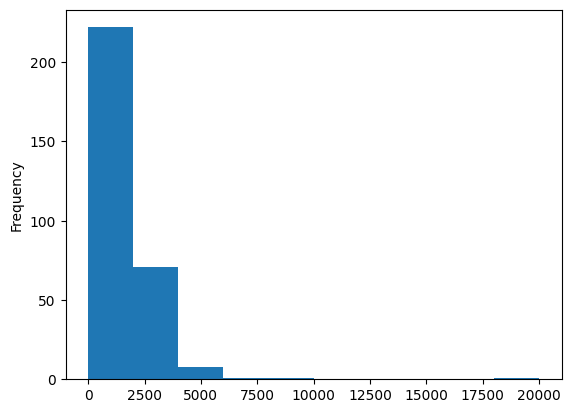

In [18]:
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

In [19]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

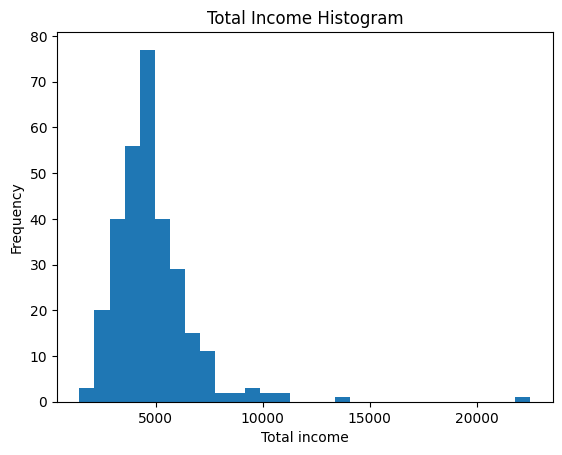

In [20]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

In [21]:
print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


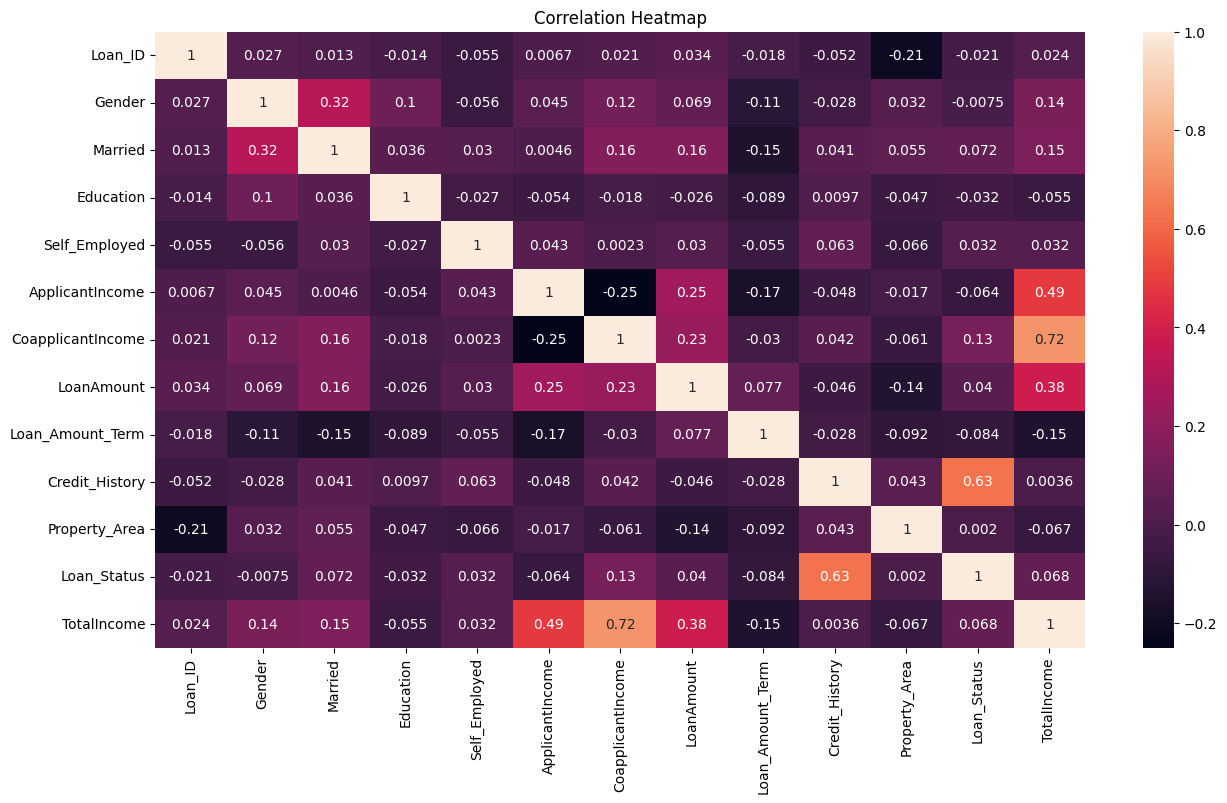

In [22]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [23]:
#dropped because the correlation coofecient between it and the loan status is low
#df = df.drop('Gender', axis = 1, errors = 'ignore')

In [24]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,55,0,0,0,0,0,4166,0.0,44.0,360.0,1.0,1,1,4166.0
1,209,1,1,0,0,0,3246,1417.0,138.0,360.0,1.0,1,1,4663.0
2,67,1,0,0,0,0,6277,0.0,118.0,360.0,0.0,0,0,6277.0
3,300,1,1,0,0,0,3232,1950.0,108.0,360.0,1.0,0,1,5182.0
4,215,1,1,2,0,0,5935,0.0,133.0,360.0,1.0,1,1,5935.0


In [25]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
299,52,1,1,1,0,0,3052,1030.0,100.0,360.0,1.0,2,1,4082.0
300,77,1,1,0,0,0,3497,1964.0,116.0,360.0,1.0,0,1,5461.0
301,213,1,1,0,0,0,2666,4300.0,121.0,360.0,1.0,0,1,6966.0
302,281,1,1,0,0,0,2785,2016.0,110.0,360.0,1.0,0,1,4801.0
303,74,1,0,0,0,0,2237,0.0,63.0,480.0,0.0,1,0,2237.0


In [26]:
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome', 'CoapplicantIncome']

In [27]:
#null values percentage
df.isna().sum()/len(df)*100

,0
Loan_ID,0.0
Gender,0.0
Married,0.0
Dependents,0.0
Education,0.0
Self_Employed,0.0
ApplicantIncome,0.0
CoapplicantIncome,0.0
LoanAmount,0.0
Loan_Amount_Term,0.0


In [62]:
#x = df[features]
#y = df['Loan_Status']

In [29]:
df['Dependents'] = df['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)

In [30]:
print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


In [33]:
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=1)
model.fit(x, y)

ValueError: could not convert string to float: '3+'

In [32]:
tdf = pd.read_csv("/content/test_data.csv")
tdf['TotalIncome'] = tdf['ApplicantIncome'] + tdf['CoapplicantIncome']
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
tdf['Gender'].fillna(tdf['Gender'].mode()[0], inplace=True)
tdf['Self_Employed'].fillna(tdf['Self_Employed'].mode()[0], inplace=True)

tdf['Loan_Amount_Term']=tdf["Loan_Amount_Term"].fillna(tdf['Loan_Amount_Term'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())

for col in categ_cols:
  tdf[col] = le.fit_transform(tdf[col])

tdf['Dependents'] = tdf['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
tdf['Dependents'] = pd.to_numeric(tdf['Dependents'], errors='coerce').fillna(0).astype(int)
print(tdf.dtypes)
x_test = tdf[features]
y_test = tdf['Loan_Status']

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


/tmp/ipykernel_708/221794456.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_708/221794456.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [34]:
predictions = model.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

AttributeError: 'GradientBoostingClassifier' object has no attribute 'estimators_'

In [35]:
predictions = model.predict(x)
print(f"Model Accuracy: {accuracy_score(y, predictions)}")

ValueError: could not convert string to float: '3+'

In [36]:
print(tdf['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
1    0.727273
0    0.272727
Name: proportion, dtype: float64


In [37]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=5)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py", line 658, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y(X, y, **check_params)
  

In [38]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

AttributeError: 'GradientBoostingClassifier' object has no attribute 'estimators_'

In [39]:
y_probs = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc: .4f}")

AttributeError: 'GradientBoostingClassifier' object has no attribute 'estimators_'

In [40]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(x_train, y_train)

NameError: name 'x_train' is not defined

In [42]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = rf.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [43]:
predictions = rf.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [44]:
predictions = rf.predict(x_train)
print(f"Model Accuracy: {accuracy_score(y_train, predictions)}")

NameError: name 'x_train' is not defined

In [45]:
from sklearn.metrics import classification_report

# This will show you exactly where the 0.8966 is coming from
print(classification_report(y_test, y_pred))


NameError: name 'y_pred' is not defined

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

In [64]:
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome', 'CoapplicantIncome']

x = df[features]
y = df['Loan_Status']


In [85]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(x, y)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [86]:
y_pred = dt_model.predict(x)
print(f"Accuracy on training data: {accuracy_score(y, y_pred):.4f}")


Accuracy on training data: 0.8882


In [87]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report: ")
print(classification_report(y, y_pred))

print("Confusion Matrix: ")
print(confusion_matrix(y, y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.63      0.77        89
           1       0.87      1.00      0.93       215

    accuracy                           0.89       304
   macro avg       0.92      0.81      0.85       304
weighted avg       0.90      0.89      0.88       304

Confusion Matrix: 
[[ 56  33]
 [  1 214]]


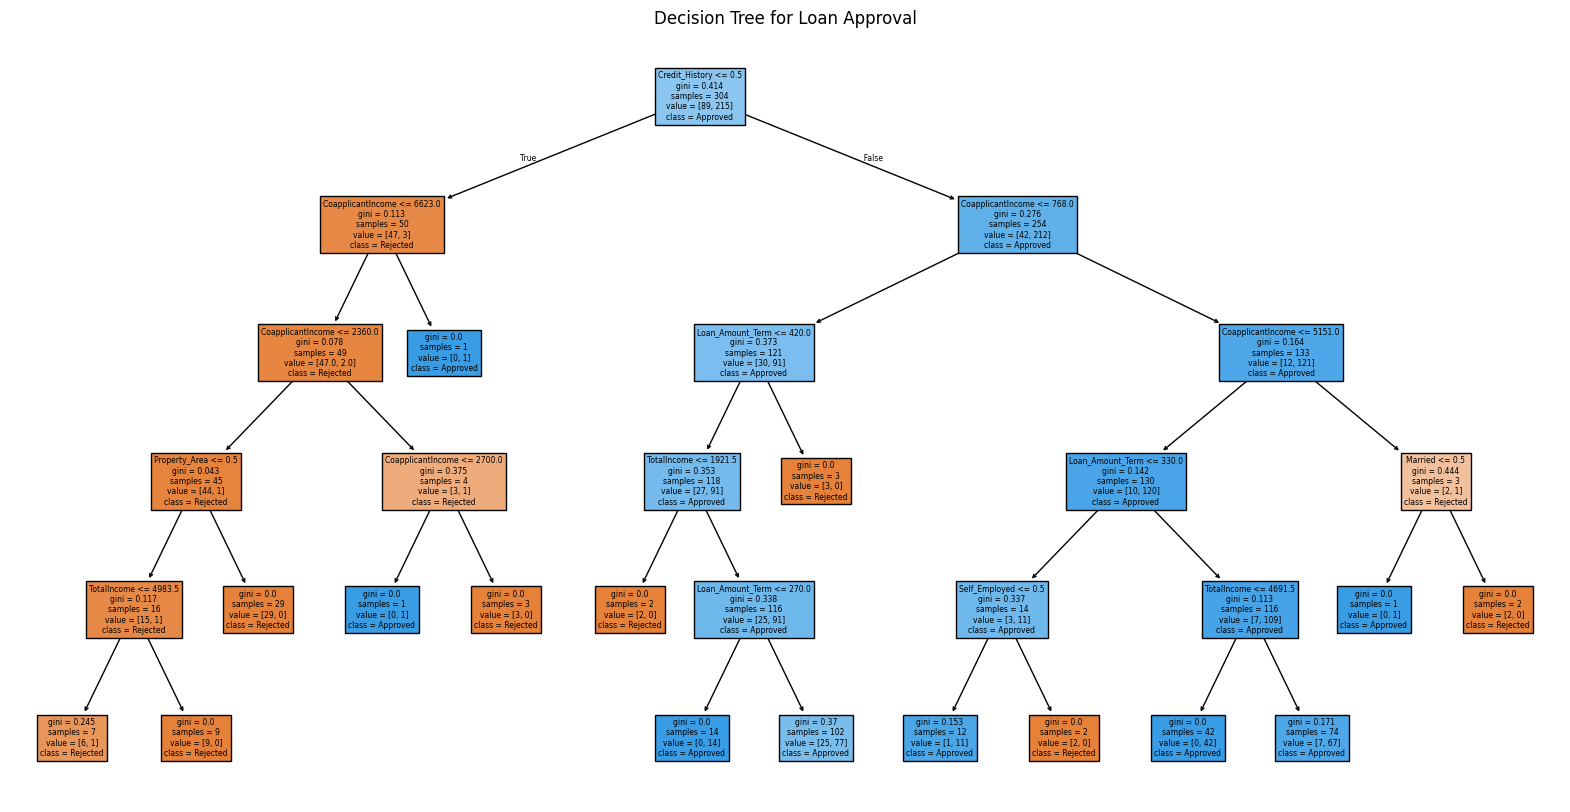

In [88]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=features, class_names=['Rejected', 'Approved'], filled=True)
plt.title("Decision Tree for Loan Approval")
plt.show()

In [89]:
importances = dt_model.feature_importances_
for name, importance in zip(features, importances):
    print(f"{name}: {importance:.4f}")

Gender: 0.0000
Married: 0.0185
Dependents: 0.0000
Education: 0.0000
Self_Employed: 0.0401
Credit_History: 0.6971
Property_Area: 0.0011
Loan_Amount_Term: 0.0772
TotalIncome: 0.0425
CoapplicantIncome: 0.1234


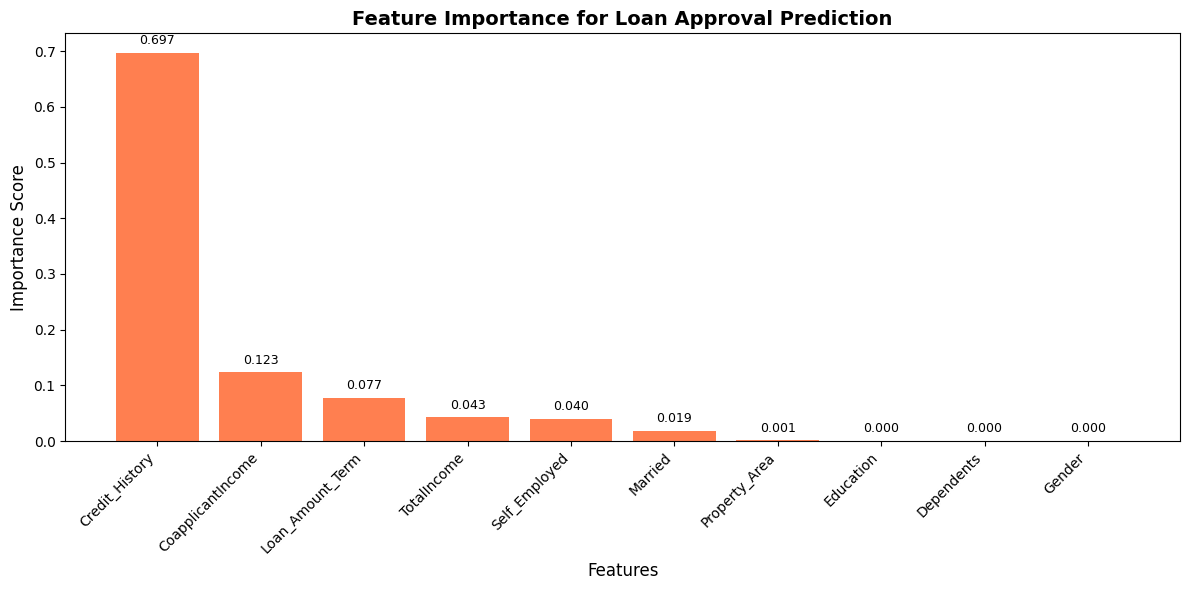

In [90]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in sorted_idx]
sorted_importances = [importances[i] for i in sorted_idx]

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_features, sorted_importances, color='coral')

for bar, value in zip(bars, sorted_importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.title('Feature Importance for Loan Approval Prediction', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [93]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(x, y)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)
best_dt = grid.best_estimator_

Best parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.8454098360655738


In [ ]:
#so no need to test on the new hyperparameters given that the best cross-validation score is way less than the original accuracy

In [102]:
tdf = pd.read_csv('test_data.csv')

print("Test data loaded!")
print(f"Test data shape: {tdf.shape}")
print("\nFirst few rows:")
print(tdf.head())


Test data loaded!
Test data shape: (77, 13)

First few rows:
    Loan_ID  Gender Married Dependents Education Self_Employed  \
0  LP002348    Male     Yes          0  Graduate            No   
1  LP001977    Male     Yes          1  Graduate            No   
2  LP001206    Male     Yes         3+  Graduate            No   
3  LP001259    Male     Yes          1  Graduate           Yes   
4  LP001265  Female      No          0  Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5829                0.0       138.0             360.0   
1             1625             1803.0        96.0             360.0   
2             3029                0.0        99.0             360.0   
3             1000             3022.0       110.0             360.0   
4             3846                0.0       111.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Rural           Y  
1             1.0      

In [103]:
tdf['Dependents'] = tdf['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
tdf['Dependents'] = pd.to_numeric(tdf['Dependents'], errors='coerce').fillna(0).astype(int)

In [104]:
tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
tdf['Gender'].fillna(tdf['Gender'].mode()[0], inplace=True)
tdf['Self_Employed'].fillna(tdf['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_708/189112245.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_708/189112245.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [105]:
tdf['Loan_Amount_Term'] = tdf["Loan_Amount_Term"].fillna(tdf['Loan_Amount_Term'].median())
tdf['Credit_History'] = tdf["Credit_History"].fillna(tdf['Credit_History'].median())

In [106]:
tdf['TotalIncome'] = tdf['ApplicantIncome'] + tdf['CoapplicantIncome']

In [114]:
le = LabelEncoder()
categ_cols = ['Gender', 'Loan_ID', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
       tdf[col] = LabelEncoder().fit_transform(tdf[col])

In [126]:
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome']
x_test = tdf[features]

In [128]:
predictions = dt_model.predict(x_test)

print("✅ Predictions complete!")
print(f"Total test samples: {len(predictions)}")
print(f"Approved: {sum(predictions)}")
print(f"Rejected: {len(predictions) - sum(predictions)}")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- CoapplicantIncome
